## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

- Melanie Haro: Software, Visualization, Project administration
- Sarah Segall: Background research, Writing - original draft, review & editing, Project administration
- Diana Estrada: Experimental investigation, Conceptualization
- Vanessa Marroquin Guzman: Data curation, Analysis, Visualization
- Lucero Felix Salazar: Background research, Methodology, Writing - review & editing

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

In our previous data checkpoint, we lost points for only including two of the four datasets in the wrangling section. In this revised submission, we have incorporated all four shelter datasets (Austin, Sonoma, Louisville, and Bloomington). Each dataset is fully loaded, cleaned, standardized, and saved to the `data/02-processed/` directory. 

For each dataset, we:
- Converted datetime columns to proper datetime format
- Examined missingness patterns
- Addressed missing values in outcome and sex-related variables
- Removed invalid or impossible records (e.g., negative shelter durations)
- Standardized relevant variables across datasets where possible

The cleaned datasets are then reloaded for exploratory data analysis. And as a result, all four datasets were harmonized to include consistent intake dates, outcome dates, and computed length-of-stay variables to support cross-city comparisons. This standardization ensures that observed differences across cities reflect accurate and genuine patterns in shelter operations rather than inconsistencies in data structure or preprocessing decisions. The cleaned datasets are then reloaded from `data/02-processed/` for exploratory data analysis.


In [11]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [12]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 
        'url': 'https://docs.google.com/spreadsheets/d/1XdAkvfhdPpZ37TaSrzX3EnFxgeB_LK_yvZ7Pp42epfA/export?format=csv',
        'filename': 'austin-texas-intakes-outcomes.csv'
    },
    { 
        'url': 'https://docs.google.com/spreadsheets/d/1uGCEULTyQrgffWznkxvEaH8wxoc2IjNR-RNCPwXcr_k/export?format=csv',
        'filename': 'sonoma-california-intake-outtakes.csv'
    },
    { 
        'url': 'https://drive.google.com/uc?export=download&id=1uzt9LkFLSQrE2CLGWHsfP86N1uegPzW_',
        'filename': 'bloomington-indiana-intakes-outcomes.csv'
    },
    { 
        'url': 'https://drive.google.com/uc?export=download&id=1cO6LSCu5F50hrs-B4BgzwyPMWYPXEJea',
        'filename': 'louisville-kentucky-intakes-outcomes.csv'
    }
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  25%|██▌       | 1/4 [00:08<00:26,  8.83s/it]

Successfully downloaded: austin-texas-intakes-outcomes.csv


Overall Download Progress:  50%|█████     | 2/4 [00:12<00:11,  5.76s/it]

Successfully downloaded: sonoma-california-intake-outtakes.csv


Overall Download Progress:  75%|███████▌  | 3/4 [00:14<00:04,  4.02s/it]

Successfully downloaded: bloomington-indiana-intakes-outcomes.csv


Overall Download Progress: 100%|██████████| 4/4 [00:17<00:00,  4.26s/it]

Successfully downloaded: louisville-kentucky-intakes-outcomes.csv


### Dataset #1: Austin, Texas Animal Shelter Dogs Intakes and Outtakes


Austin (raw) shape: (79672, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79672 entries, 0 to 79671
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age_upon_outcome            79672 non-null  object 
 1   animal_id_outcome           79672 non-null  object 
 2   date_of_birth               79672 non-null  object 
 3   outcome_subtype             36348 non-null  object 
 4   outcome_type                79662 non-null  object 
 5   sex_upon_outcome            79671 non-null  object 
 6   age_upon_outcome_(days)     79672 non-null  int64  
 7   age_upon_outcome_(years)    79672 non-null  float64
 8   age_upon_outcome_age_group  79672 non-null  object 
 9   outcome_datetime            79672 non-null  object 
 10  outcome_month               79672 non-null  int64  
 11  outcome_year                79672 non-null  int64  
 12  outcome_monthyear           79672 non-null  object 
 13 

outcome_subtype              54.377950
outcome_type                  0.012551
sex_upon_outcome              0.001255
sex_upon_intake               0.001255
age_upon_outcome              0.000000
age_upon_intake_age_group     0.000000
found_location                0.000000
intake_condition              0.000000
intake_type                   0.000000
count                         0.000000
age_upon_intake_(days)        0.000000
age_upon_intake_(years)       0.000000
intake_month                  0.000000
intake_datetime               0.000000
breed                         0.000000
dtype: float64

outcome_subtype,False,True
outcome_type,,
Adoption,0.173870,0.826130
Died,0.872464,0.127536
Disposal,0.000000,1.000000
Euthanasia,0.972133,0.027867
Missing,0.760870,0.239130
Relocate,0.000000,1.000000
Return to Owner,0.000068,0.999932
Rto-Adopt,0.000000,1.000000
Transfer,1.000000,0.000000


Austin (clean) shape: (79662, 42)


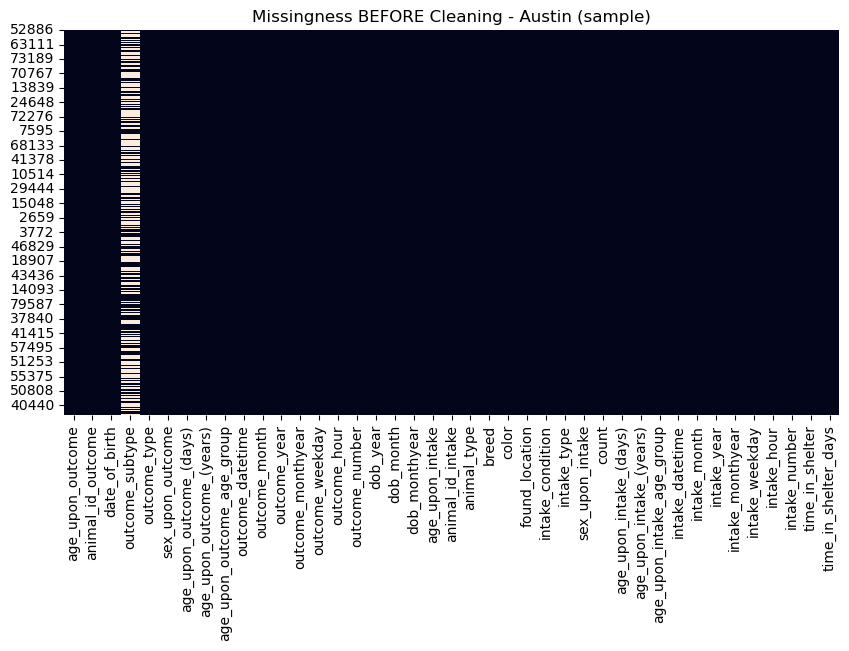

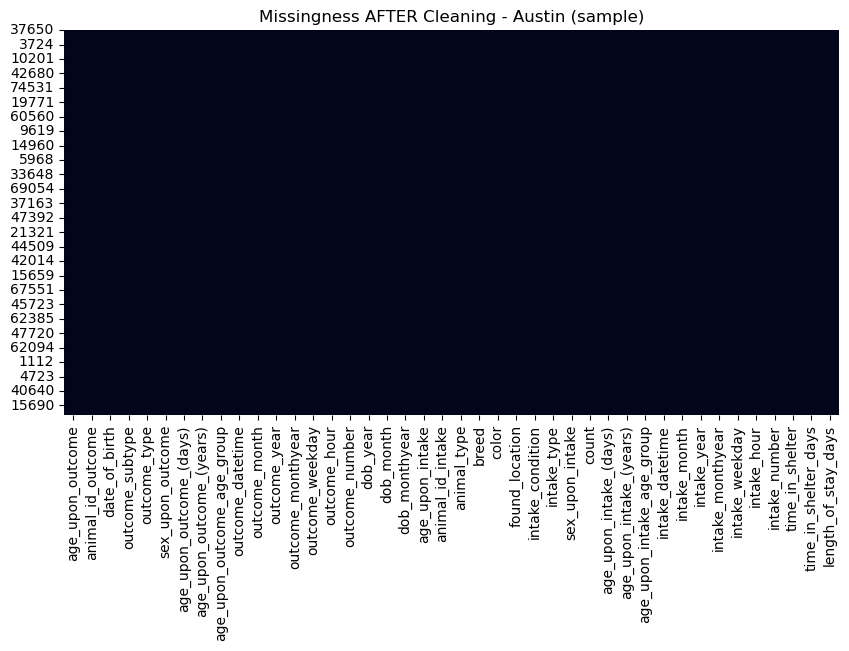

In [13]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Dataset: Austin (raw load)
# -------------------------
austin_raw = pd.read_csv("data/00-raw/austin-texas-intakes-outcomes.csv")
austin = austin_raw.copy()

pd.set_option("display.max_columns", None)

print("Austin (raw) shape:", austin.shape)
austin.info()

# -------------------------
# Missingness overview
# -------------------------
missing_pct = (austin.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(15))

# Missingness pattern for outcome_subtype (often conditional on outcome_type)
missing_subtype = pd.crosstab(
    austin["outcome_type"],
    austin["outcome_subtype"].isna(),
    normalize="index"
)
display(missing_subtype)

# -------------------------
# Cleaning / Wrangling
# -------------------------

# Fill outcome_subtype NA as "Not Applicable" (structural missingness)
austin["outcome_subtype"] = austin["outcome_subtype"].fillna("Not Applicable")

# Convert datetimes safely
austin["date_of_birth"] = pd.to_datetime(austin["date_of_birth"], errors="coerce")
austin["intake_datetime"] = pd.to_datetime(austin["intake_datetime"], errors="coerce")
austin["outcome_datetime"] = pd.to_datetime(austin["outcome_datetime"], errors="coerce")

# Drop rows missing the core outcome label (central to analysis; very small count)
austin = austin.dropna(subset=["outcome_type"]).copy()

# Fill small sex missingness
austin["sex_upon_outcome"] = austin["sex_upon_outcome"].fillna("Unknown")
austin["sex_upon_intake"] = austin["sex_upon_intake"].fillna("Unknown")

# Compute length of stay in days
# Austin has time_in_shelter_days already, but we also compute LOS from datetimes as a cross-check.
austin["length_of_stay_days"] = (
    (austin["outcome_datetime"] - austin["intake_datetime"]).dt.total_seconds() / (60 * 60 * 24)
)

# Remove impossible LOS values (negative or missing due to bad timestamps)
austin = austin[
    austin["length_of_stay_days"].notna() &
    (austin["length_of_stay_days"] >= 0)
].copy()

print("Austin (clean) shape:", austin.shape)

# -------------------------
# Save processed dataset
# -------------------------
os.makedirs("data/02-processed", exist_ok=True)
austin.to_csv("data/02-processed/austin_clean.csv", index=False)

# -------------------------
# Missingness visualization
# -------------------------
plt.figure(figsize=(10, 5))
sns.heatmap(austin_raw.sample(2000, random_state=0).isna(), cbar=False)
plt.title("Missingness BEFORE Cleaning - Austin (sample)")
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(austin.sample(2000, random_state=0).isna(), cbar=False)
plt.title("Missingness AFTER Cleaning - Austin (sample)")
plt.show()

The Austin dataset contains 79,672 observations and 41 variables. Missingness is concentrated in `outcome_subtype`, which is conditionally dependent on `outcome_type` and therefore treated as structural rather than random. Datetime columns were standardized, and rows missing the primary outcome label were removed. Length of stay in days was calculated using intake and outcome timestamps, and negative or invalid durations were excluded to ensure consistency for downstream analysis.

### Dataset #2: Louisville Metro Animal Shelter Intake and Outcome Records
 

Louisville (raw) shape: (56567, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56567 entries, 0 to 56566
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   kennel         56567 non-null  object
 1   animalid       56567 non-null  object
 2   jurisdiction   45315 non-null  object
 3   intype         56567 non-null  object
 4   insubtype      56363 non-null  object
 5   indate         56567 non-null  object
 6   surreason      45315 non-null  object
 7   outtype        44853 non-null  object
 8   outsubtype     36554 non-null  object
 9   outdate        44887 non-null  object
 10  animaltype     56567 non-null  object
 11  sex            55675 non-null  object
 12  bites          45328 non-null  object
 13  petsize        54517 non-null  object
 14  color          56566 non-null  object
 15  breed          56493 non-null  object
 16  sourcezipcode  47711 non-null  object
 17  ObjectId       56567 non-null  in

outsubtype       35.379285
outtype          20.708187
outdate          20.648081
jurisdiction     19.891456
surreason        19.891456
bites            19.868475
sourcezipcode    15.655771
petsize           3.624021
sex               1.576891
insubtype         0.360634
breed             0.130818
color             0.001768
kennel            0.000000
animaltype        0.000000
animalid          0.000000
dtype: float64

outtype,False,True
intype,,
APPOINTMNT,1.000000,0.000000
CONFISCATE,0.972735,0.027265
DISPOSAL,0.691275,0.308725
FOR TRANSP,0.875000,0.125000
FOSTER,0.997103,0.002897
FOUND,0.001383,0.998617
LOST,0.000000,1.000000
OWNER SUR,0.994815,0.005185
RETURN,0.993092,0.006908


Louisville (clean) shape: (44847, 19)


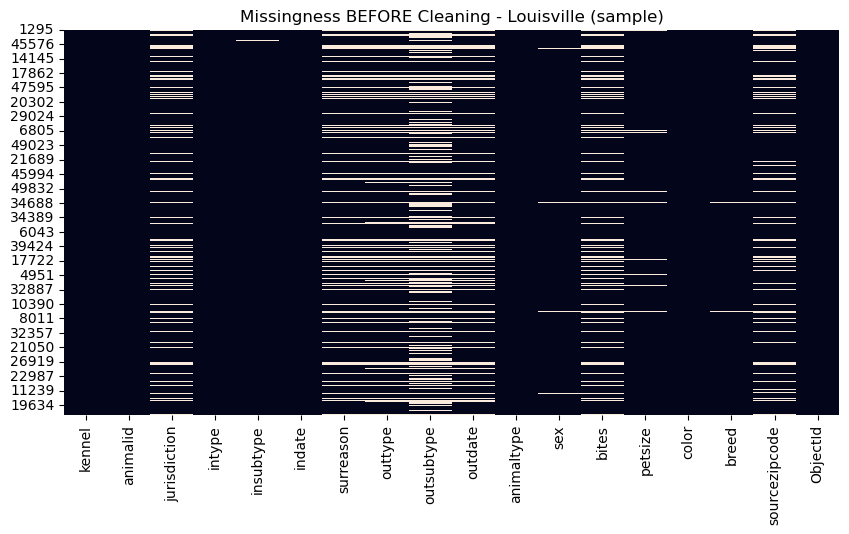

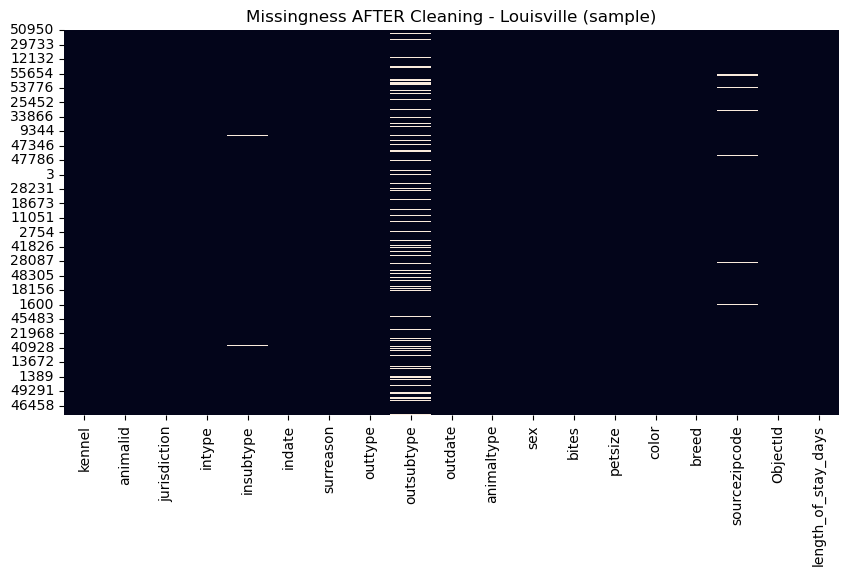

In [17]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Dataset: Louisville (raw load)
# -------------------------
louisville_raw = pd.read_csv("data/00-raw/louisville-kentucky-intakes-outcomes.csv")
louisville = louisville_raw.copy()

pd.set_option("display.max_columns", None)

print("Louisville (raw) shape:", louisville.shape)
louisville.info()

# -------------------------
# Missingness overview
# -------------------------
missing_pct = (louisville.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(15))

# Optional: show that outdate/outtype missingness is structural (animals without outcomes yet)
out_missing = pd.crosstab(louisville["intype"], louisville["outtype"].isna(), normalize="index")
display(out_missing)

# -------------------------
# Cleaning / Wrangling
# -------------------------

# Standardize column names (strip whitespace)
louisville.columns = louisville.columns.str.strip()

# Convert dates safely
louisville["indate"] = pd.to_datetime(louisville["indate"], errors="coerce")
louisville["outdate"] = pd.to_datetime(louisville["outdate"], errors="coerce")

# Drop rows missing core outcome info (needed for outcome analysis + LOS)
louisville = louisville.dropna(subset=["outtype", "outdate"]).copy()

# Fill small categorical missingness
louisville["sex"] = louisville["sex"].fillna("Unknown")
louisville["petsize"] = louisville["petsize"].fillna("Unknown")
louisville["breed"] = louisville["breed"].fillna("Unknown")
louisville["color"] = louisville["color"].fillna("Unknown")

# Compute length of stay in days
louisville["length_of_stay_days"] = (
    (louisville["outdate"] - louisville["indate"]).dt.total_seconds() / (60 * 60 * 24)
)

# Remove invalid durations
louisville = louisville[
    louisville["length_of_stay_days"].notna() &
    (louisville["length_of_stay_days"] >= 0)
].copy()

print("Louisville (clean) shape:", louisville.shape)

# -------------------------
# Save processed dataset
# -------------------------
os.makedirs("data/02-processed", exist_ok=True)
louisville.to_csv("data/02-processed/louisville_clean.csv", index=False)

# -------------------------
# Missingness visualization (sample)
# -------------------------
plt.figure(figsize=(10, 5))
sns.heatmap(louisville_raw.sample(2000, random_state=0).isna(), cbar=False)
plt.title("Missingness BEFORE Cleaning - Louisville (sample)")
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(louisville.sample(2000, random_state=0).isna(), cbar=False)
plt.title("Missingness AFTER Cleaning - Louisville (sample)")
plt.show()

The Louisville dataset contains 56,567 observations and 18 variables. Missingness is concentrated in outcome-related fields (`outtype`, `outdate`), which likely represent animals that had not yet exited the shelter at the time of data export. For analyses focused on completed outcomes, rows missing outcome information were removed. Intake and outcome dates were converted to datetime format, and length of stay in days was calculated and validated to remove invalid durations.

### Dataset #3: Sonoma, California Animal Shelter Dogs Intakes and Outtakes
 

Sonoma (raw) shape: (32601, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32601 entries, 0 to 32600
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  24064 non-null  object 
 1   Type                  32601 non-null  object 
 2   Breed                 32601 non-null  object 
 3   Color                 32601 non-null  object 
 4   Sex                   32601 non-null  object 
 5   Size                  32564 non-null  object 
 6   Date Of Birth         24803 non-null  object 
 7   Impound Number        32601 non-null  object 
 8   Kennel Number         32593 non-null  object 
 9   Animal ID             32601 non-null  object 
 10  Intake Date           32601 non-null  object 
 11  Outcome Date          32423 non-null  object 
 12  Days in Shelter       32601 non-null  object 
 13  Intake Type           32601 non-null  object 
 14  Intake Subtype        32601 non-null  

Name                    26.186313
Date Of Birth           23.919512
Outcome Jurisdiction    14.373792
Location                14.303242
Outcome Zip Code        14.248029
Outcome Condition        1.693200
Outcome Subtype          1.644121
Outcome Type             0.567467
Outcome Date             0.545996
Size                     0.113493
Kennel Number            0.024539
Intake Subtype           0.000000
Intake Jurisdiction      0.000000
Intake Condition         0.000000
Days in Shelter          0.000000
dtype: float64

Outcome Zip Code,False,True
Outcome Type,,
ADOPTION,0.997521,0.002479
DIED,0.156780,0.843220
DISPOSAL,0.251462,0.748538
ESCAPED/STOLEN,0.210526,0.789474
EUTHANIZE,0.198444,0.801556
RETURN TO OWNER,0.980069,0.019931
RTOS,1.000000,0.000000
SHELTER,0.850000,0.150000
TRANSFER,0.971815,0.028185


Location,False,True
Outcome Type,,
ADOPTION,0.996982,0.003018
DIED,0.156780,0.843220
DISPOSAL,0.251462,0.748538
ESCAPED/STOLEN,0.210526,0.789474
EUTHANIZE,0.198222,0.801778
RETURN TO OWNER,0.979324,0.020676
RTOS,1.000000,0.000000
SHELTER,0.850000,0.150000
TRANSFER,0.971257,0.028743


Outcome Jurisdiction,False,True
Outcome Type,,
ADOPTION,0.991486,0.008514
DIED,0.161017,0.838983
DISPOSAL,0.251462,0.748538
ESCAPED/STOLEN,0.210526,0.789474
EUTHANIZE,0.198667,0.801333
RETURN TO OWNER,0.982211,0.017789
RTOS,0.975309,0.024691
SHELTER,0.850000,0.150000
TRANSFER,0.970978,0.029022


Negative Days in Shelter: 0
Outcome Date before Intake Date: 0
Sonoma (clean) shape: (32416, 24)


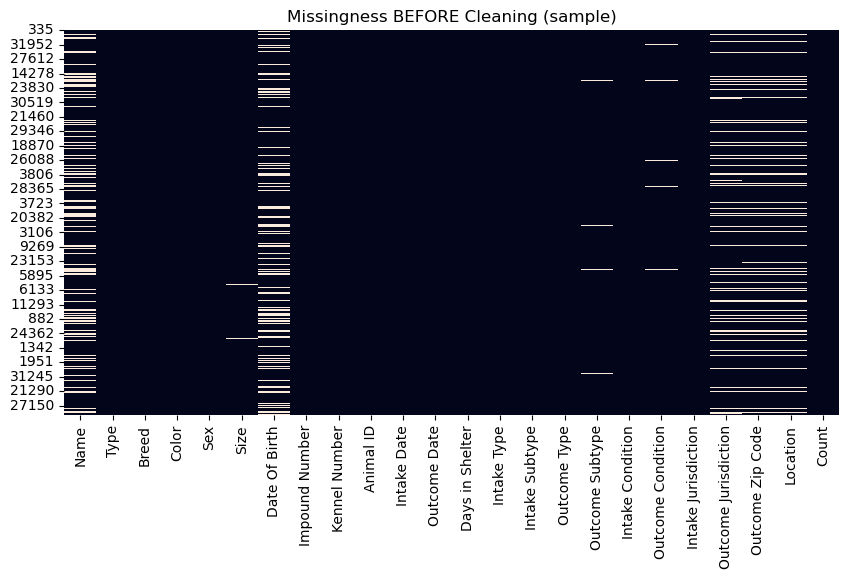

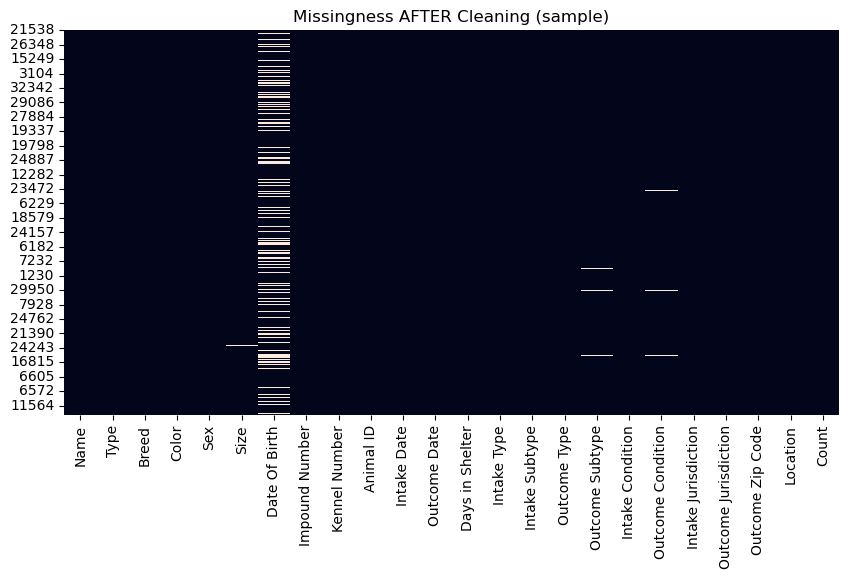

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Load raw dataset
sonoma_raw = pd.read_csv("data/00-raw/sonoma-california-intake-outtakes.csv")
sonoma = sonoma_raw.copy()

pd.set_option("display.max_columns", None)

# Basic structure
print("Sonoma (raw) shape:", sonoma.shape)
sonoma.info()

# Missingness overview (percent)
missing_pct = (sonoma.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(15))

# Missingness patterns for location/jurisdiction/zip by outcome type
# (helps justify that missingness is structural / related to outcome type)
zip_missing = pd.crosstab(sonoma["Outcome Type"], sonoma["Outcome Zip Code"].isna(), normalize="index")
location_missing = pd.crosstab(sonoma["Outcome Type"], sonoma["Location"].isna(), normalize="index")
juri_missing = pd.crosstab(sonoma["Outcome Type"], sonoma["Outcome Jurisdiction"].isna(), normalize="index")

display(zip_missing)
display(location_missing)
display(juri_missing)

# --- Cleaning / Wrangling ---

# Convert columns to datetime / numeric safely
sonoma["Intake Date"] = pd.to_datetime(sonoma["Intake Date"], errors="coerce")
sonoma["Outcome Date"] = pd.to_datetime(sonoma["Outcome Date"], errors="coerce")
sonoma["Days in Shelter"] = pd.to_numeric(sonoma["Days in Shelter"], errors="coerce")

# Logical checks (report counts so we can decide what to do)
neg_days = (sonoma["Days in Shelter"] < 0).sum()
outcome_before_intake = (sonoma["Outcome Date"] < sonoma["Intake Date"]).sum()
print("Negative Days in Shelter:", neg_days)
print("Outcome Date before Intake Date:", outcome_before_intake)

# Drop rows missing core outcome information (small fraction, central to analysis)
sonoma = sonoma.dropna(subset=["Outcome Type", "Outcome Date"]).copy()

# Handle structural missingness
sonoma["Name"] = sonoma["Name"].fillna("Unknown")

# Zip/jurisdiction/location are often not applicable depending on outcome type
sonoma["Outcome Zip Code"] = sonoma["Outcome Zip Code"].fillna(-1)
sonoma["Outcome Jurisdiction"] = sonoma["Outcome Jurisdiction"].fillna("Not Applicable")
sonoma["Location"] = sonoma["Location"].fillna("Not Recorded")

# Date of Birth often unknown; keep as NaT instead of dropping rows
sonoma["Date Of Birth"] = pd.to_datetime(sonoma["Date Of Birth"], errors="coerce")

print("Sonoma (clean) shape:", sonoma.shape)

# Save cleaned dataset
os.makedirs("data/02-processed", exist_ok=True)
sonoma.to_csv("data/02-processed/sonoma_clean.csv", index=False)

# --- Missingness visualization (sample for readability) ---
plt.figure(figsize=(10, 5))
sns.heatmap(sonoma_raw.sample(2000, random_state=0).isna(), cbar=False)
plt.title("Missingness BEFORE Cleaning (sample)")
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(sonoma.sample(2000, random_state=0).isna(), cbar=False)
plt.title("Missingness AFTER Cleaning (sample)")
plt.show()

The Sonoma dataset contains 32,601 observations and 24 variables. Missingness is primarily structural, particularly in variables such as `Name` and `Date Of Birth`, which reflect unknown information rather than data entry errors. Outcome-related columns were standardized to datetime format, and rows missing core outcome information were removed. Shelter duration was validated and cleaned to eliminate invalid negative values, resulting in a consistent dataset for outcome and length-of-stay analysis.

### Dataset #4: Bloomington, Indiana Intakes and Outcomes

Bloomington (raw) shape: (42865, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42865 entries, 0 to 42864
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                42865 non-null  int64 
 1   intakedate        42865 non-null  object
 2   intakereason      42863 non-null  object
 3   istransfer        42865 non-null  bool  
 4   sheltercode       42865 non-null  object
 5   identichipnumber  38213 non-null  object
 6   animalname        42865 non-null  object
 7   breedname         42786 non-null  object
 8   basecolour        42865 non-null  object
 9   speciesname       42865 non-null  object
 10  animalage         42865 non-null  object
 11  sexname           42865 non-null  object
 12  location          42865 non-null  object
 13  movementdate      36276 non-null  object
 14  movementtype      36276 non-null  object
 15  istrial           42865 non-null  bool  
 16  returndate        139

deceaseddate        96.477312
returndate          67.381313
movementdate        15.371515
movementtype        15.371515
identichipnumber    10.852677
breedname            0.184300
intakereason         0.004666
id                   0.000000
puttosleep           0.000000
diedoffshelter       0.000000
deceasedreason       0.000000
returnedreason       0.000000
istrial              0.000000
sexname              0.000000
location             0.000000
dtype: float64

movementtype,False,True
speciesname,,
Bat,1.000000,0.000000
Bird,0.933824,0.066176
Cat,0.885748,0.114252
Chicken,1.000000,0.000000
Chinchilla,0.888889,0.111111
Dog,0.783599,0.216401
Ferret,1.000000,0.000000
Fish,1.000000,0.000000
Gerbil,1.000000,0.000000


/var/folders/t7/v9b6p7y53h7bqd9d5b1vy6mm0000gn/T/ipykernel_2891/1654582625.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bloomington["intakedate"] = pd.to_datetime(bloomington["intakedate"], errors="coerce")
/var/folders/t7/v9b6p7y53h7bqd9d5b1vy6mm0000gn/T/ipykernel_2891/1654582625.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bloomington["movementdate"] = pd.to_datetime(bloomington["movementdate"], errors="coerce")


Bloomington (clean) shape: (33512, 24)


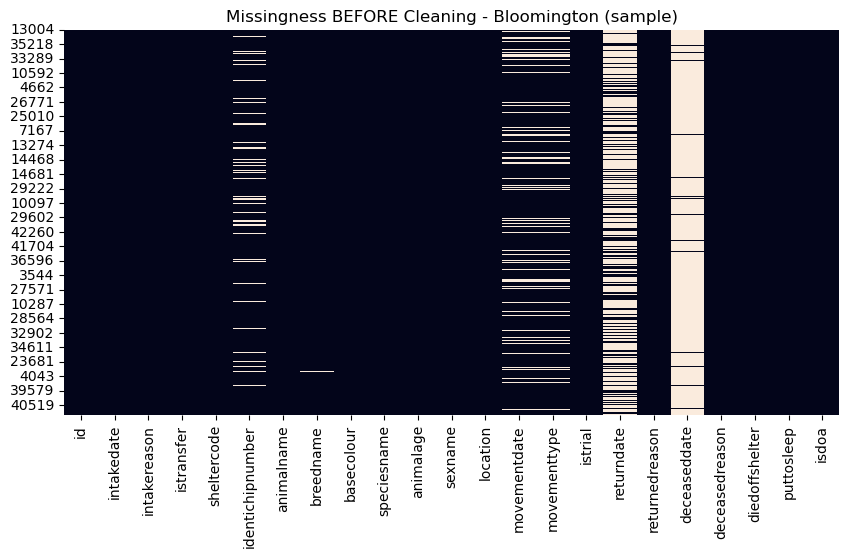

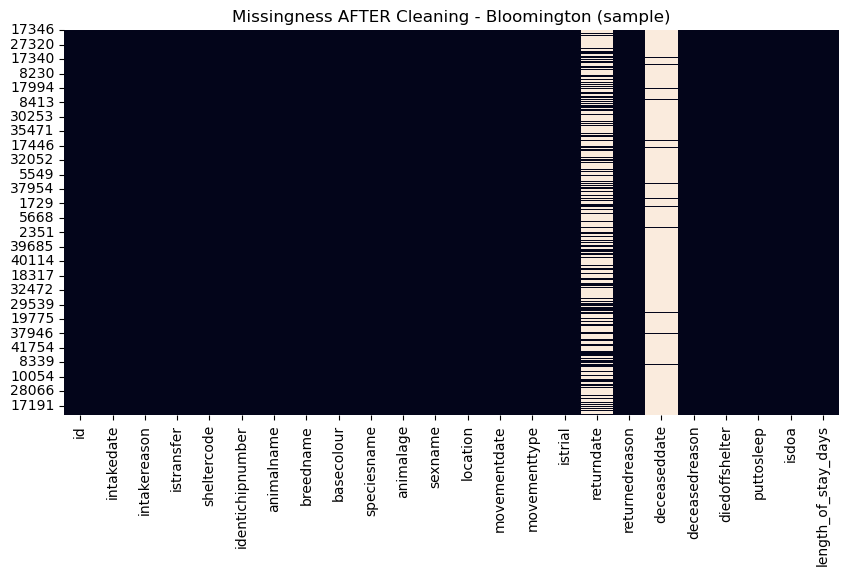

In [20]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Dataset: Bloomington (raw load)
# -------------------------
bloomington_raw = pd.read_csv("data/00-raw/bloomington-indiana-intakes-outcomes.csv")
bloomington = bloomington_raw.copy()

pd.set_option("display.max_columns", None)

print("Bloomington (raw) shape:", bloomington.shape)
bloomington.info()

# -------------------------
# Missingness overview
# -------------------------
missing_pct = (bloomington.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(15))

# Show outcome missingness pattern
movement_missing = pd.crosstab(
    bloomington["speciesname"],
    bloomington["movementtype"].isna(),
    normalize="index"
)
display(movement_missing)

# -------------------------
# Cleaning / Wrangling
# -------------------------

# Standardize column names
bloomington.columns = bloomington.columns.str.strip()

# Convert date columns safely
bloomington["intakedate"] = pd.to_datetime(bloomington["intakedate"], errors="coerce")
bloomington["movementdate"] = pd.to_datetime(bloomington["movementdate"], errors="coerce")

# Convert age if needed (may contain text like "2 years")
bloomington["animalage"] = bloomington["animalage"].astype(str)

# Drop rows missing outcome information (needed for outcome analysis + LOS)
bloomington = bloomington.dropna(subset=["movementtype", "movementdate"]).copy()

# Fill minor categorical missingness
bloomington["breedname"] = bloomington["breedname"].fillna("Unknown")
bloomington["identichipnumber"] = bloomington["identichipnumber"].fillna("Not Recorded")

# Compute length of stay in days
bloomington["length_of_stay_days"] = (
    (bloomington["movementdate"] - bloomington["intakedate"]).dt.total_seconds() / (60 * 60 * 24)
)

# Remove invalid durations
bloomington = bloomington[
    bloomington["length_of_stay_days"].notna() &
    (bloomington["length_of_stay_days"] >= 0)
].copy()

print("Bloomington (clean) shape:", bloomington.shape)

# -------------------------
# Save processed dataset
# -------------------------
os.makedirs("data/02-processed", exist_ok=True)
bloomington.to_csv("data/02-processed/bloomington_clean.csv", index=False)

# -------------------------
# Missingness visualization (sample)
# -------------------------
plt.figure(figsize=(10, 5))
sns.heatmap(bloomington_raw.sample(2000, random_state=0).isna(), cbar=False)
plt.title("Missingness BEFORE Cleaning - Bloomington (sample)")
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(bloomington.sample(2000, random_state=0).isna(), cbar=False)
plt.title("Missingness AFTER Cleaning - Bloomington (sample)")
plt.show()

The Bloomington dataset contains 42,865 observations and 23 variables. Missingness is primarily associated with movement-related fields (`movementtype`, `movementdate`), which indicate whether an animal has exited the shelter. Rows lacking outcome information were removed to ensure consistency in outcome-based analyses. Datetime columns were standardized, and length of stay in days was computed and validated to align with the other city datasets.

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### RQ1 EDA: Age at Intake and Adoption Probability

- line plot where each line represents a city and then each line shows the trend/correlation in each city

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

age_order = [
    'Puppy (0-6m)',
    'Juvenile (6-18m)',
    'Young Adult (1.5-3y)',
    'Adult (3-7y)',
    'Senior (7+y)'

]

def process_city(df, city_name):

    df['adopted'] = np.where(df['outcome'] == 'Adoption', 1, 0)

    def age_bin(age):
        if age < 0.5:
            return 'Puppy (0-6m)'
        elif age < 1.5:
            return 'Juvenile (6-18m)'
        elif age < 3:
            return 'Young Adult (1.5-3y)'
        elif age < 7:
            return 'Adult (3-7y)'
        else:
            return 'Senior (7+y)'

df['age_bin'] = df['age_years'].apply(age_bin)
df['age_bin'] = pd.Categorical(df['age_bin'], categories=age_order, ordered=True)

model = smf.logit('adopted ~ C(age_bin)', data=df).fit(disp=0)

pred_df = pd.DataFrame({"age_bin": age_order})
pred_df['city'] = city_name
pred_df['pred_prob'] = model.predict(pred_df)

return pred_df

austin_pred = process_city(austin_df, 'Austin')
sonoma_pred = process_city(sonoma_df, 'Sonoma')
indiana_pred = process_city(indiana_df, 'Indiana')

pred_df_all = pd.concat([austin_pred, sonoma_pred, indiana_pred])

plt.figure(figsize=(10,6))

sns.lineplot(
    data = pred_df_all,
    x = 'age_bin'
    y = pred_prob
    hue = 'city',
    marker ='o'
)

plt.xticks(rotation=45)
plt.ylabel('Predicted Probability of Adoption')
plt.xlabel('Age Category')
plt.title('Adoption Probability by Age Category and City')

plt.tight_layout()
plt.show

#### RQ2 EDA: Purebred vs. Mixed-Breed Status and Adoption Rates

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### RQ3 EDA: Length of Stay and Adoption Probability

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them